In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"nowayte","key":"54239b66326321593da59c786dbe3b16"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d shivamb/vehicle-claim-fraud-detection -p /content --force
!unzip -o /content/vehicle-claim-fraud-detection.zip -d /content/vehicle_fraud_data
!ls -lah /content/vehicle_fraud_data

Dataset URL: https://www.kaggle.com/datasets/shivamb/vehicle-claim-fraud-detection
License(s): CC0-1.0
  0% 0.00/348k [00:00<?, ?B/s]
100% 348k/348k [00:00<00:00, 644MB/s]
Archive:  /content/vehicle-claim-fraud-detection.zip
  inflating: /content/vehicle_fraud_data/fraud_oracle.csv  
total 3.5M
drwxr-xr-x 2 root root 4.0K Mar  9 23:02 .
drwxr-xr-x 1 root root 4.0K Mar  9 23:02 ..
-rw-r--r-- 1 root root 3.5M Dec 20  2021 fraud_oracle.csv


In [4]:
import os
import glob
import pandas as pd

data_dir = "/content/vehicle_fraud_data"
csv_files = glob.glob(os.path.join(data_dir, "*.csv"))

if not csv_files:
    raise FileNotFoundError("No CSV files found after unzip. Check the dataset contents.")

print("Found CSV files:")
for f in csv_files:
    print("-", os.path.basename(f))
df = pd.read_csv(csv_files[0])
print("\nDataset shape:", df.shape)
df.head()

Found CSV files:
- fraud_oracle.csv

Dataset shape: (15420, 33)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [5]:
print("Columns:\n", df.columns)
print("\nTarget distribution:")
print(df["FraudFound_P"].value_counts(dropna=False))

Columns:
 Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber',
       'Deductible', 'DriverRating', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year',
       'BasePolicy'],
      dtype='object')

Target distribution:
FraudFound_P
0    14497
1      923
Name: count, dtype: int64


In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_score, recall_score, f1_score, average_precision_score
)

# Separate features/target
X = df.drop(columns=["FraudFound_P", "PolicyNumber", "RepNumber"], errors="ignore")
y = df["FraudFound_P"]

# Identify column types
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("Numeric cols:", len(num_cols), "| Categorical cols:", len(cat_cols))

# Preprocess
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
print("\nModel Performance (Test Set):")
print(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_pipeline = trained_models[best_model_name]

best_y_pred = best_pipeline.predict(X_test)
best_y_prob = best_pipeline.predict_proba(X_test)[:, 1]

print(f"\nBest Model: {best_model_name}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, best_y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, best_y_pred, digits=4, zero_division=0))

print("ROC-AUC:", roc_auc_score(y_test, best_y_prob))
print("PR-AUC:", average_precision_score(y_test, best_y_prob))

Numeric cols: 6 | Categorical cols: 24


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model Performance (Test Set):
                 Model  Precision    Recall  F1-score   ROC-AUC    PR-AUC
2    Gradient Boosting   0.565217  0.046931  0.086667  0.835789  0.235201
1        Random Forest   1.000000  0.010830  0.021429  0.826782  0.241062
0  Logistic Regression   0.166667  0.003610  0.007067  0.807466  0.171941

Best Model: Gradient Boosting

Confusion Matrix:
[[4339   10]
 [ 264   13]]

Classification Report:

              precision    recall  f1-score   support

           0     0.9426    0.9977    0.9694      4349
           1     0.5652    0.0469    0.0867       277

    accuracy                         0.9408      4626
   macro avg     0.7539    0.5223    0.5280      4626
weighted avg     0.9200    0.9408    0.9165      4626

ROC-AUC: 0.8357890481483357
PR-AUC: 0.23520052645630765


Top 15 important features:
cat__BasePolicy_Liability                  0.161839
cat__Fault_Third Party                     0.158878
cat__AddressChange_Claim_2 to 3 years      0.134165
cat__Fault_Policy Holder                   0.095461
num__Age                                   0.052449
cat__PolicyType_Sedan - Collision          0.045441
num__Year                                  0.034710
cat__AddressChange_Claim_under 6 months    0.016718
cat__MonthClaimed_Sep                      0.016106
cat__PolicyType_Sport - Collision          0.015965
cat__Make_Accura                           0.014551
cat__AgeOfVehicle_4 years                  0.013876
cat__Month_Mar                             0.012559
cat__MonthClaimed_Nov                      0.010465
cat__DayOfWeekClaimed_Sunday               0.009116
dtype: float64


Text(0.5, 0, 'Importance')

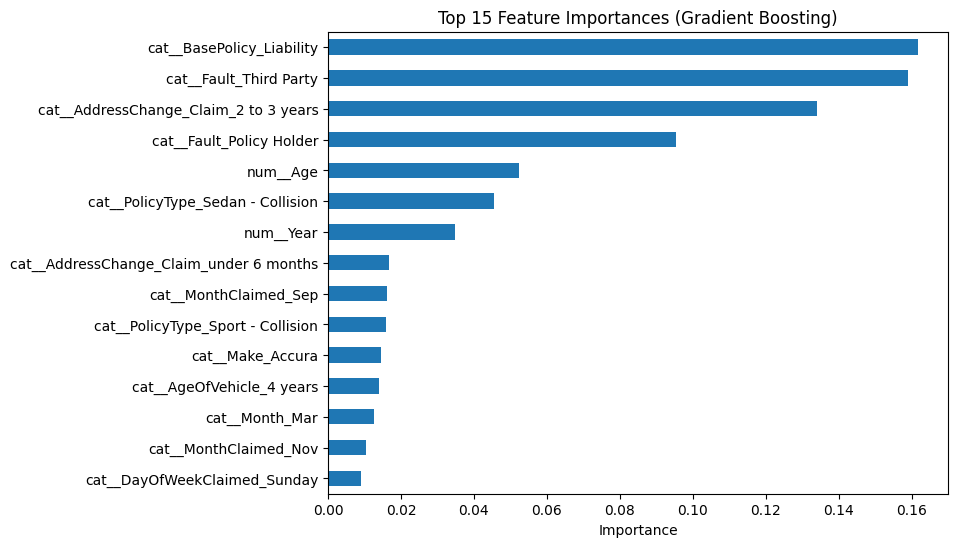

In [13]:
import pandas as pd
import numpy as np # Ensure numpy is imported for potential use elsewhere, though not strictly needed for this fix.

# feature names after preprocessing
# Use best_pipeline instead of clf
# Get feature names directly from the ColumnTransformer to ensure correct alignment with model's feature_importances_
all_feature_names = best_pipeline.named_steps["preprocess"].get_feature_names_out()

# Get importances from the best model
importances = best_pipeline.named_steps["model"].feature_importances_
fi = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

print("Top 15 important features:")
print(fi.head(15))

ax = fi.head(15).sort_values().plot(kind="barh", figsize=(8, 6))
# Update plot title to reflect the actual best model being used
ax.set_title(f"Top 15 Feature Importances ({best_model_name})")
ax.set_xlabel("Importance")

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_score, recall_score, f1_score, average_precision_score
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

# -----------------------------
# 1. Prepare data
# -----------------------------
X = df.drop(columns=["FraudFound_P", "PolicyNumber", "RepNumber"], errors="ignore")
y = df["FraudFound_P"]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("Numeric cols:", len(num_cols), "| Categorical cols:", len(cat_cols))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# -----------------------------
# 2. Preprocessing
# NOTE: sparse_output=False so SMOTE can work
# -----------------------------
numeric_transformer = SkPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = SkPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

# -----------------------------
# 3. Sampling strategies
# -----------------------------
sampling_strategies = {
    "No Balancing": None,
    "Random Oversampling": RandomOverSampler(random_state=42),
    "Random Undersampling": RandomUnderSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "SMOTEENN": SMOTEENN(random_state=42),
}

results = []
trained_pipelines = {}

# -----------------------------
# 4. Train and evaluate
# -----------------------------
for name, sampler in sampling_strategies.items():
    steps = [("preprocess", preprocess)]

    if sampler is not None:
        steps.append(("sampler", sampler))

    steps.append(("model", GradientBoostingClassifier(random_state=42)))

    pipeline = ImbPipeline(steps=steps)

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Sampling Method": name,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

    trained_pipelines[name] = pipeline

results_imbalance_df = pd.DataFrame(results).sort_values(by="Recall", ascending=False)

print("\nExperiment 2 Results: Class Imbalance Handling")
print(results_imbalance_df)

Numeric cols: 6 | Categorical cols: 24

Experiment 2 Results: Class Imbalance Handling
        Sampling Method  Precision    Recall  F1-score   ROC-AUC    PR-AUC
1   Random Oversampling   0.138008  0.895307  0.239151  0.847748  0.279073
2  Random Undersampling   0.127049  0.895307  0.222521  0.821338  0.220675
4              SMOTEENN   0.167754  0.649819  0.266667  0.822383  0.189162
0          No Balancing   0.565217  0.046931  0.086667  0.835789  0.235201
3                 SMOTE   0.600000  0.043321  0.080808  0.826930  0.230589


In [15]:
best_sampling_name = results_imbalance_df.iloc[0]["Sampling Method"]
best_sampling_pipeline = trained_pipelines[best_sampling_name]

best_y_pred = best_sampling_pipeline.predict(X_test)
best_y_prob = best_sampling_pipeline.predict_proba(X_test)[:, 1]

print(f"\nBest Sampling Method by Recall: {best_sampling_name}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, best_y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, best_y_pred, digits=4, zero_division=0))

print("ROC-AUC:", roc_auc_score(y_test, best_y_prob))
print("PR-AUC:", average_precision_score(y_test, best_y_prob))


Best Sampling Method by Recall: Random Oversampling

Confusion Matrix:
[[2800 1549]
 [  29  248]]

Classification Report:

              precision    recall  f1-score   support

           0     0.9897    0.6438    0.7802      4349
           1     0.1380    0.8953    0.2392       277

    accuracy                         0.6589      4626
   macro avg     0.5639    0.7696    0.5097      4626
weighted avg     0.9387    0.6589    0.7478      4626

ROC-AUC: 0.8477478950719406
PR-AUC: 0.2790729830025899


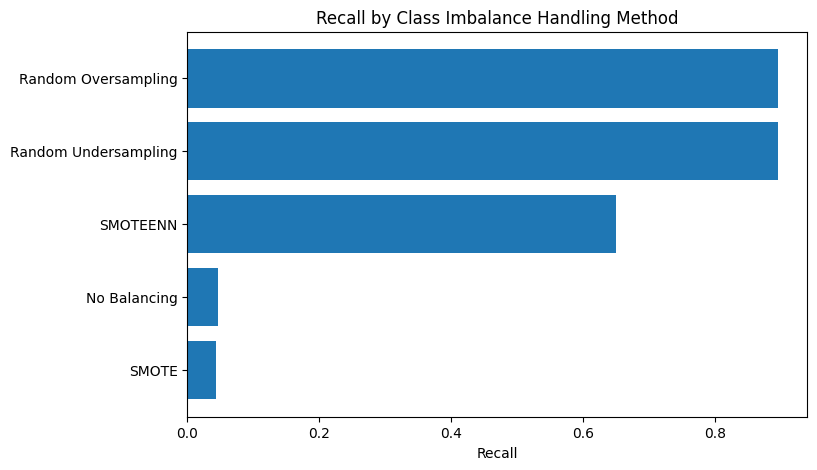

In [16]:
import matplotlib.pyplot as plt

plot_df = results_imbalance_df.sort_values(by="Recall", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["Sampling Method"], plot_df["Recall"])
plt.xlabel("Recall")
plt.title("Recall by Class Imbalance Handling Method")
plt.show()

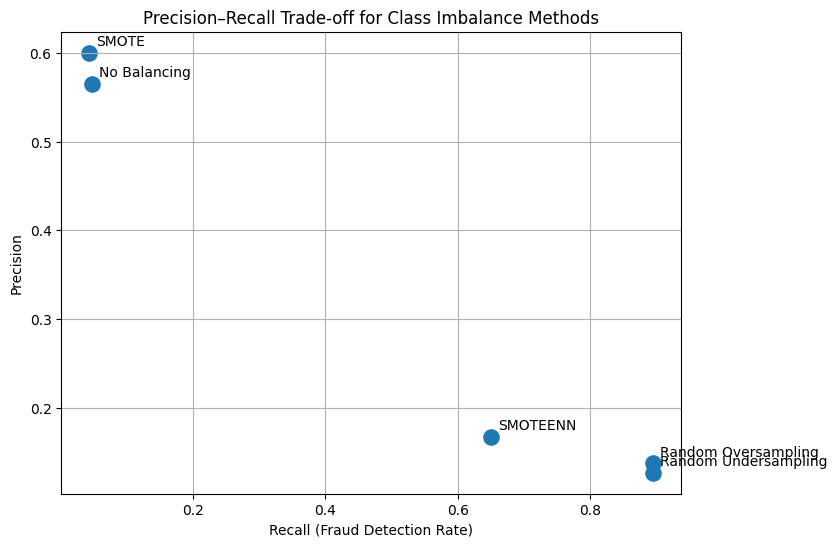

In [17]:
import matplotlib.pyplot as plt

plot_df = results_imbalance_df.copy()

plt.figure(figsize=(8,6))

plt.scatter(plot_df["Recall"], plot_df["Precision"], s=120)

for i, txt in enumerate(plot_df["Sampling Method"]):
    plt.annotate(txt, (plot_df["Recall"].iloc[i], plot_df["Precision"].iloc[i]),
                 xytext=(5,5), textcoords='offset points')

plt.xlabel("Recall (Fraud Detection Rate)")
plt.ylabel("Precision")
plt.title("Precision–Recall Trade-off for Class Imbalance Methods")

plt.grid(True)
plt.show()

In [18]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

feature_sets = {
    "Policy Features": [
        "PolicyType", "BasePolicy", "Deductible",
        "VehicleCategory", "DriverRating"
    ],

    "Claim Features": [
        "Fault", "WeekOfMonth", "WeekOfMonthClaimed",
        "MonthClaimed", "AgeOfVehicle"
    ],

    "All Features": list(X.columns)
}

results_feature_sets = []

for name, cols in feature_sets.items():

    X_subset = X[cols]

    cat_cols = X_subset.select_dtypes(include=["object"]).columns.tolist()
    num_cols = [c for c in X_subset.columns if c not in cat_cols]

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocess = ColumnTransformer([
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ])

    pipeline = ImbPipeline([
        ("preprocess", preprocess),
        ("sampler", RandomOverSampler(random_state=42)),
        ("model", GradientBoostingClassifier(random_state=42))
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X_subset, y, test_size=0.30, random_state=42, stratify=y
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:,1]

    results_feature_sets.append({
        "Feature Set": name,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

results_feature_df = pd.DataFrame(results_feature_sets)
results_feature_df

,Feature Set,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Policy Features,0.084746,0.956679,0.155699,0.688657,0.117550
1,Claim Features,0.085518,0.765343,0.153846,0.670337,0.095500
2,All Features,0.138008,0.895307,0.239151,0.847748,0.279073


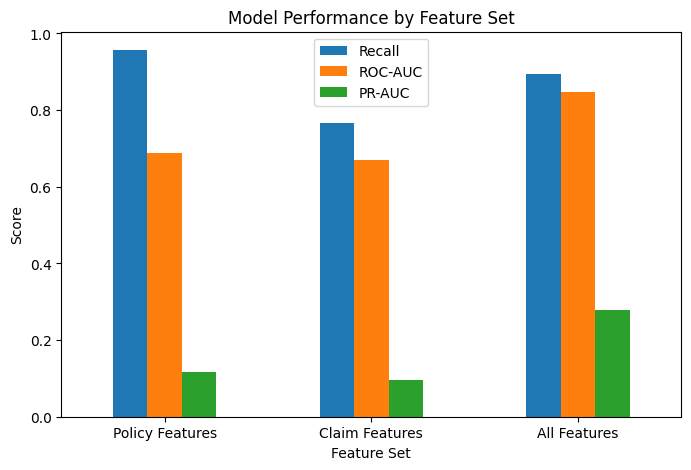

In [19]:
import matplotlib.pyplot as plt

plot_df = results_feature_df.copy()

metrics = ["Recall", "ROC-AUC", "PR-AUC"]

plot_df.set_index("Feature Set")[metrics].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance by Feature Set")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

# Full feature set
X = df.drop(columns=["FraudFound_P", "PolicyNumber", "RepNumber"], errors="ignore")
y = df["FraudFound_P"]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

numeric_transformer = SkPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = SkPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

best_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("sampler", RandomOverSampler(random_state=42)),
    ("model", GradientBoostingClassifier(random_state=42))
])

best_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['WeekOfMonth',
                                                   'WeekOfMonthClaimed', 'Age',
                                                   'Deductible', 'DriverRating',
                                                   'Year']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=Fa...
                                                   'VehicleCategory',
                                                   'VehiclePrice',
                                                   'Days_Policy_Accident',
                                                   'Days_Policy_Claim',
                                                   'PastNumberOfClaims',
                                                   'AgeOfVehicle',
                                                   'AgeOfPolicyHolder',
                                                   'PoliceReportFiled',
                                                   'WitnessPresent',
                                                   'AgentType',
                                                   'NumberOfSuppliments',
                                                   'AddressChange_Claim',
                                                   'NumberOfCars',
                                                   'BasePolicy'])])),
                ('sampler', RandomOverSampler(random_state=42)),
                ('model', GradientBoostingClassifier(random_state=42))])

In [21]:
# Transform test data using the fitted preprocessor
X_test_transformed = best_pipeline.named_steps["preprocess"].transform(X_test)

# Get feature names after one-hot encoding
ohe = best_pipeline.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)

feature_names = np.concatenate([num_cols, cat_feature_names])

X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)
X_test_transformed_df.head()

,WeekOfMonth,WeekOfMonthClaimed,Age,Deductible,DriverRating,Year,Month_Apr,Month_Aug,Month_Dec,Month_Feb,...,AddressChange_Claim_no change,AddressChange_Claim_under 6 months,NumberOfCars_1 vehicle,NumberOfCars_2 vehicles,NumberOfCars_3 to 4,NumberOfCars_5 to 8,NumberOfCars_more than 8,BasePolicy_All Perils,BasePolicy_Collision,BasePolicy_Liability
0,2.0,3.0,46.0,400.0,1.0,1996.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2.0,2.0,36.0,400.0,3.0,1996.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,4.0,1.0,48.0,400.0,4.0,1994.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,5.0,2.0,36.0,400.0,1.0,1994.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,3.0,3.0,39.0,400.0,1.0,1994.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [22]:
import shap

model = best_pipeline.named_steps["model"]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed_df)

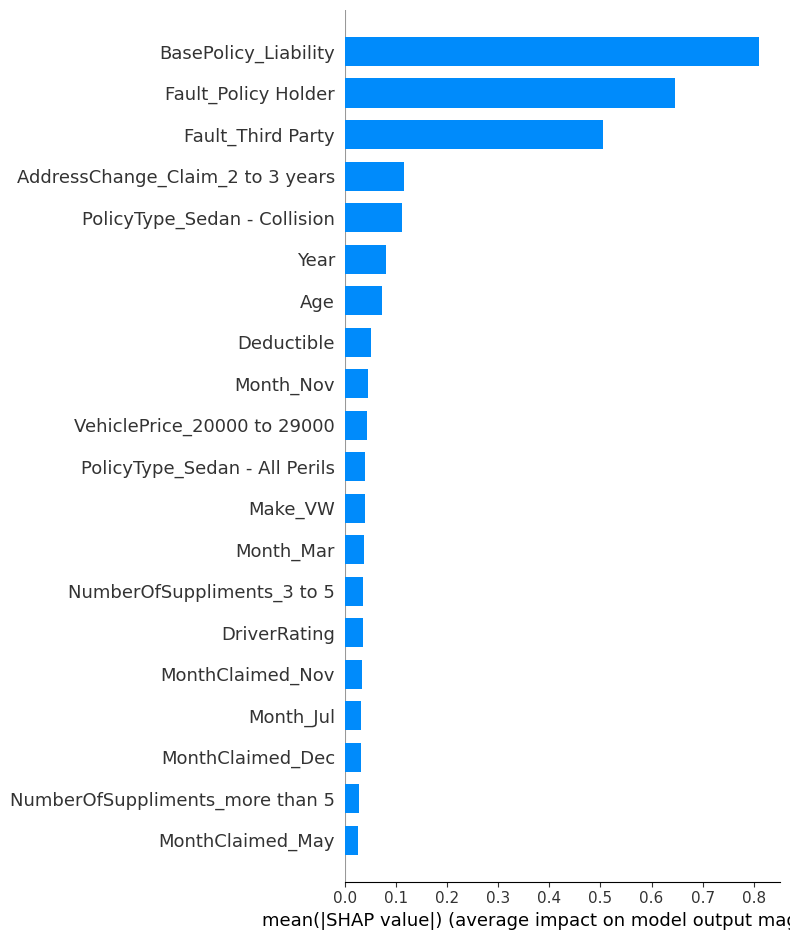

In [23]:
shap.summary_plot(shap_values, X_test_transformed_df, plot_type="bar")

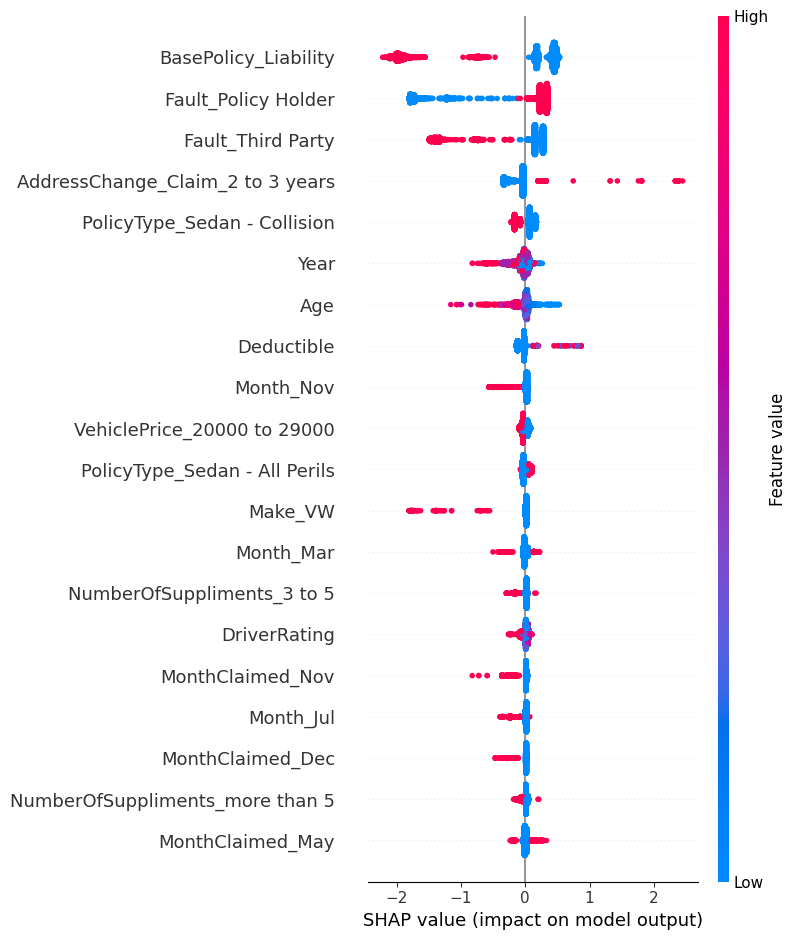

In [24]:
shap.summary_plot(shap_values, X_test_transformed_df)

In [25]:
# Find one fraud case from the test set
fraud_indices = y_test[y_test == 1].index

# pick the first fraud case
sample_idx = fraud_indices[0]

# locate its position inside X_test
sample_position = X_test.index.get_loc(sample_idx)

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_position],
    X_test_transformed_df.iloc[sample_position]
)

In [26]:
# mean absolute shap values
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values(by="MeanAbsSHAP", ascending=False)

print("Top 15 SHAP Features:")
print(shap_importance_df.head(15))

Top 15 SHAP Features:
                              Feature  MeanAbsSHAP
145              BasePolicy_Liability     0.810643
73                Fault_Policy Holder     0.645953
74                  Fault_Third Party     0.504500
134  AddressChange_Claim_2 to 3 years     0.115975
76       PolicyType_Sedan - Collision     0.112628
5                                Year     0.081095
2                                 Age     0.073129
3                          Deductible     0.051944
15                          Month_Nov     0.044617
87        VehiclePrice_20000 to 29000     0.044057
75      PolicyType_Sedan - All Perils     0.040259
43                            Make_VW     0.039525
13                          Month_Mar     0.037519
130        NumberOfSuppliments_3 to 5     0.035840
4                        DriverRating     0.035243


In [27]:
import json
import joblib
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

# Load dataset
df = pd.read_csv("/content/vehicle_fraud_data/fraud_oracle.csv")

# Prepare data
X = df.drop(columns=["FraudFound_P", "PolicyNumber", "RepNumber"], errors="ignore")
y = df["FraudFound_P"]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Preprocessing
numeric_transformer = SkPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = SkPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

# Best model pipeline
best_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("sampler", RandomOverSampler(random_state=42)),
    ("model", GradientBoostingClassifier(random_state=42))
])

# Train
best_pipeline.fit(X_train, y_train)

# Save full pipeline
joblib.dump(best_pipeline, "fraud_triage_pipeline.joblib")

# Save form metadata
metadata = {
    "categorical_columns": cat_cols,
    "numeric_columns": num_cols,
    "categorical_options": {
        col: sorted([str(v) for v in X[col].dropna().unique().tolist()])
        for col in cat_cols
    },
    "numeric_defaults": {
        col: float(X[col].median()) for col in num_cols
    }
}

with open("fraud_triage_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print("- fraud_triage_pipeline.joblib")
print("- fraud_triage_metadata.json")

Saved:
- fraud_triage_pipeline.joblib
- fraud_triage_metadata.json
